In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv("global_greenhouse_gas_emission_from_agriculture.csv")
data.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Source Code,Source,Unit,Value,Flag,Flag Description,Note
0,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1990,1990,3050,FAO TIER 1,kt,214.4467,E,Estimated value,NaN
1,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1991,1991,3050,FAO TIER 1,kt,224.1393,E,Estimated value,NaN
2,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1992,1992,3050,FAO TIER 1,kt,226.7224,E,Estimated value,NaN
3,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1993,1993,3050,FAO TIER 1,kt,228.5003,E,Estimated value,NaN
4,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1994,1994,3050,FAO TIER 1,kt,236.9822,E,Estimated value,NaN


    Analysis strategy

-> General plots ( KDE ) with respect to time ( year ) and gas, countries.

-> Which is the largest gas emitted in last 3 years.

-> Which country is at the top in green house gas emittion ( Top 4 and then other in pie chart ).

-> Same point as the above  but this time specific to gas.

-> In which year the green house gas emittion was high ( Bar Chart ).


**GETTING BASIC INFO ABOUT DATASET**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22216 entries, 0 to 22215
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       22216 non-null  object 
 1   Domain            22216 non-null  object 
 2   Area Code (M49)   22216 non-null  int64  
 3   Area              22216 non-null  object 
 4   Element Code      22216 non-null  int64  
 5   Element           22216 non-null  object 
 6   Item Code         22216 non-null  int64  
 7   Item              22216 non-null  object 
 8   Year Code         22216 non-null  int64  
 9   Year              22216 non-null  int64  
 10  Source Code       22216 non-null  int64  
 11  Source            22216 non-null  object 
 12  Unit              22216 non-null  object 
 13  Value             22216 non-null  float64
 14  Flag              22216 non-null  object 
 15  Flag Description  22216 non-null  object 
 16  Note              0 non-null      float6

In [ ]:
data.describe()

,Area Code (M49),Element Code,Item Code,Year Code,Year,Source Code,Value,Note
count,22216.000000,22216.000000,22216.0,22216.000000,22216.000000,22216.0,2.221600e+04,0.0
mean,436.902008,7242.692114,6995.0,2005.622344,2005.622344,3050.0,8.487653e+03,NaN
std,253.450163,21.551371,0.0,9.183770,9.183770,0.0,6.420424e+04,NaN
min,4.000000,7225.000000,6995.0,1990.000000,1990.000000,3050.0,0.000000e+00,NaN
25%,218.000000,7225.000000,6995.0,1998.000000,1998.000000,3050.0,1.946475e+00,NaN
50%,434.000000,7230.000000,6995.0,2006.000000,2006.000000,3050.0,3.849290e+01,NaN
75%,659.000000,7273.000000,6995.0,2014.000000,2014.000000,3050.0,7.815779e+02,NaN
max,894.000000,7273.000000,6995.0,2021.000000,2021.000000,3050.0,1.660373e+06,NaN


In [ ]:
country_counts = data['Area'].value_counts()
country_counts

,count
Area,
Afghanistan,96
Albania,96
Algeria,96
American Samoa,96
Andorra,96
...,...
Ethiopia PDR,9
Czechoslovakia,9
USSR,6


In [ ]:
data.drop("Note", axis = 1)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Source Code,Source,Unit,Value,Flag,Flag Description
0,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1990,1990,3050,FAO TIER 1,kt,214.4467,E,Estimated value
1,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1991,1991,3050,FAO TIER 1,kt,224.1393,E,Estimated value
2,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1992,1992,3050,FAO TIER 1,kt,226.7224,E,Estimated value
3,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1993,1993,3050,FAO TIER 1,kt,228.5003,E,Estimated value
4,GT,Emissions totals,4,Afghanistan,7225,Emissions (CH4),6995,Emissions on agricultural land,1994,1994,3050,FAO TIER 1,kt,236.9822,E,Estimated value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22211,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2017,2017,3050,FAO TIER 1,kt,15.4064,E,Estimated value
22212,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2018,2018,3050,FAO TIER 1,kt,15.4385,E,Estimated value
22213,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2019,2019,3050,FAO TIER 1,kt,15.0984,E,Estimated value
22214,GT,Emissions totals,716,Zimbabwe,7230,Emissions (N2O),6995,Emissions on agricultural land,2020,2020,3050,FAO TIER 1,kt,13.4151,E,Estimated value


In [ ]:
elements = data.groupby(["Element", "Area"]).size().reset_index(name="count")
elements

,Element,Area,count
0,Emissions (CH4),Afghanistan,32
1,Emissions (CH4),Albania,32
2,Emissions (CH4),Algeria,32
3,Emissions (CH4),American Samoa,32
4,Emissions (CH4),Andorra,32
...,...,...,...
723,Emissions (N2O),Western Sahara,32
724,Emissions (N2O),Yemen,32
725,Emissions (N2O),Yugoslav SFR,2
726,Emissions (N2O),Zambia,32


**CHECKING DISTRIBUTION OF ELEMENTS**

<Axes: xlabel='Year', ylabel='Density'>

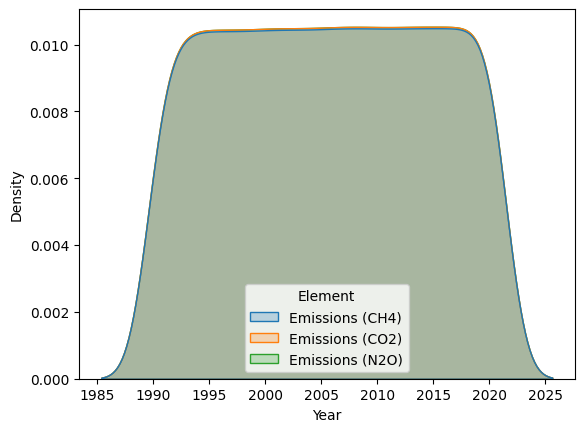

In [ ]:
sns.kdeplot(
    data=data,
    x='Year',
    hue='Element',
    fill=True
)


 My guess: This dataset was the subset of some larger dataset which is why many column values were same accross rows like domain domain code source flag description etc.
 I fetched the columns : Element , Year, Area , value

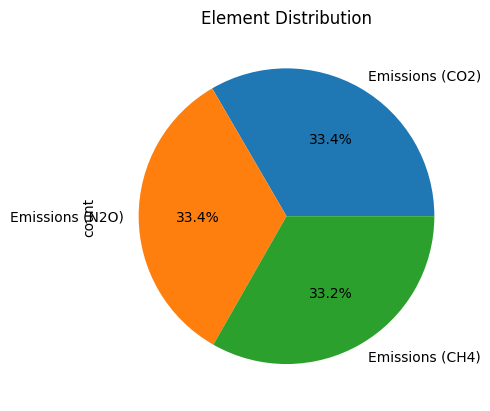

In [ ]:
newData = data[[ "Element", "Area","Year", "Value"]]

newData.head()


e = newData["Element"].unique()
e_counts = newData["Element"].value_counts()
e_counts.plot(kind="pie", autopct='%1.1f%%')
plt.title("Element Distribution")
plt.show()

It seems the data is equally distributed

**JUST PLAYING WITH PIE CHART**

Text(0.5, 1.0, 'Country Distribution')

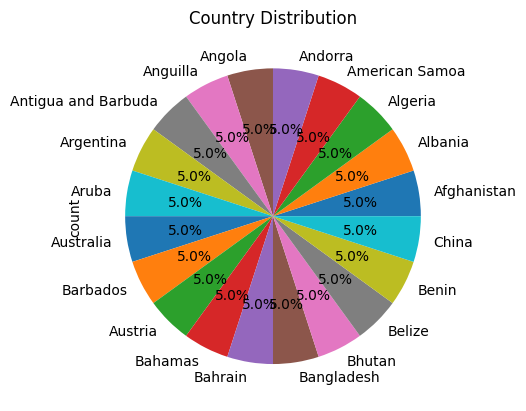

In [ ]:
con = newData['Area'].unique()
con_c = newData["Area"].value_counts().head(20)
con_c.plot(kind="pie", autopct='%1.1f%%')
plt.title("Country Distribution")


Text(0.5, 1.0, 'Country Distribution')

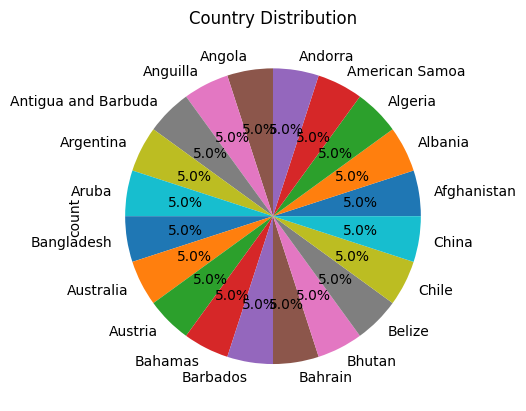

In [ ]:

em = newData[newData['Element'] == 'Emissions (CH4)']
em
em1 = newData[newData['Element'] == 'Emissions (N2O)']
em1
em2 = newData[newData['Element'] == 'Emissions (CO2)']
em2
data = [em, em1, em2]

# Top 10 countries in CH4 emission

e_plot =  em["Area"].value_counts().head(20)
e_plot.plot(kind="pie", autopct='%1.1f%%')
plt.title("Country Distribution")

# array(['Emissions (CH4)', 'Emissions (CO2)', 'Emissions (N2O)'],
#       dtype=object)

**CHECKING DISTRIBUTION ON THE BASIS OF VALUES**

264959.1141
4869338.999299999
183427390.47079998


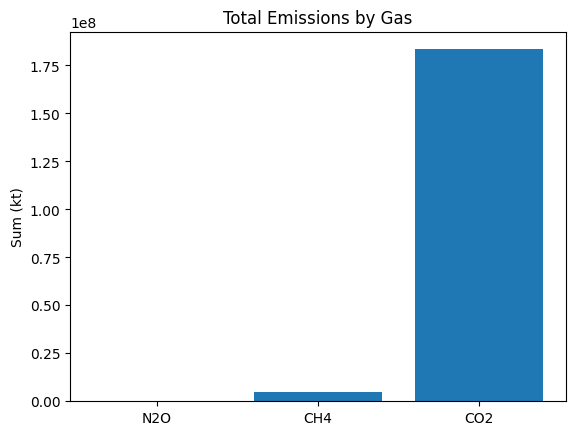

In [ ]:
s = newData[newData['Element'] == 'Emissions (N2O)']
a = s["Value"].sum()
print(a)

s1 = newData[newData['Element'] == 'Emissions (CH4)']
a1 = s1["Value"].sum()
print(a1)

s2 = newData[newData['Element'] == 'Emissions (CO2)']
a2 = s2["Value"].sum()
print(a2)

sums_dict = {'N2O': a, 'CH4': a1, 'CO2': a2}
gases = list(sums_dict.keys())
values = list(sums_dict.values())

plt.bar(gases, values)
plt.title('Total Emissions by Gas')
plt.ylabel('Sum (kt)')
plt.show()


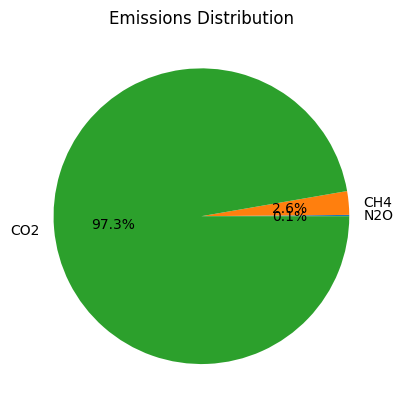

In [ ]:
plt.pie(values, labels=gases, autopct='%1.1f%%')
plt.title('Emissions Distribution')
plt.show()

Observation: The largest emitted gas in past 30 years is Co2. Where other gases are very less compare to this.

FILTERING COUNTRIES WITH LARGEST CO2 EMITSION

In [ ]:
# Which country has the largest CO2 emittsion
co2_by_area = s2.groupby('Area')['Value'].sum().sort_values(ascending=False)

v = co2_by_area.head(9).sum()
print((v / a2) * 100)

co2_by_area.head(9)
# max_area = co2_by_area.idxmax()
# max_value = co2_by_area.max()
# print(f"Area with largest CO2: {max_area} ({max_value} kt) {(max_value / a2) * 100}")



# min_area = co2_by_area.idxmin()
# min_value = co2_by_area.min()
# print(f"Area with largest CO2: {min_area} ({min_value} kt) {(m_value / a2) * 100}")



60.7177163180706


,Value
Area,
Brazil,3.973053e+07
Indonesia,2.483785e+07
Democratic Republic of the Congo,1.433437e+07
China,7.353461e+06
"China, mainland",7.225167e+06
Canada,5.115553e+06
United States of America,4.898870e+06
India,4.012805e+06
Myanmar,3.864317e+06


Observation: About 21 percent of Co2 gas is emitted from brazil out of 220 countries listed. Also Island is the country with zero co2 emitsion

**ANALYSING TRENDS ACCROSS YEARS**

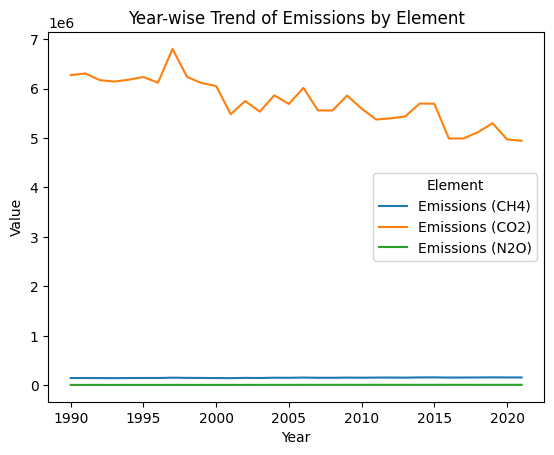

In [ ]:
trend = (
    newData.groupby(['Year', 'Element'])['Value']
      .sum()
      .reset_index()
)


sns.lineplot(
    data=trend,
    x='Year',
    y='Value',
    hue='Element'
)

plt.title('Year-wise Trend of Emissions by Element')
plt.show()

Conslusion: The amount of emition of co2 is decreasing by seeing the past 30 years data. Where CH4 and No2 is constant throughout

In [ ]:
counts_df = data.groupby('Element').agg(
    count=('Element', 'size'),
    total_value=('Value', 'sum')  # Or use 'mean', 'first', 'max', etc.
).reset_index()


In [ ]:
hello = data.groupby("Area").size().reset_index(name = "count")
hello = hello.sort_values(by='count', ascending=False)
similar = hello.groupby("count").size().reset_index(name = "Same Count")
similar = similar.sort_values(by='Same Count', ascending=False )
similar

,count,Same Count
12,96,200
10,90,19
11,93,4
9,87,4
3,30,3
8,66,3
5,48,2
1,6,2
2,9,2
4,42,1


In [ ]:
# Top 15 emitting countries for each gas type
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('🏆 Top 15 Countries by Greenhouse Gas Emissions (Total 1990-2021)',
             fontsize=16, fontweight='bold', y=0.995)

gases = df_clean['Element'].unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (gas, color) in enumerate(zip(gases, colors)):
    data = df_clean[df_clean['Element'] == gas].groupby('Area')['Value'].sum().sort_values(ascending=False).head(15)

    axes[idx].barh(range(len(data)), data.values, color=color, alpha=0.8, edgecolor='black')
    axes[idx].set_yticks(range(len(data)))
    axes[idx].set_yticklabels(data.index, fontsize=10)
    axes[idx].set_xlabel('Total Emissions (kt)', fontsize=11)
    axes[idx].set_title(f'{gas}', fontsize=13, fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, v in enumerate(data.values):
        axes[idx].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

GET GOINGS

Selection of graphs was very imperssive interactive graphs looks cool
